In [ ]:
!pip install missingno

### 데이터 확인

In [14]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(df_train.shape, df_test.shape)

(891, 12) (418, 11)


In [16]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [19]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


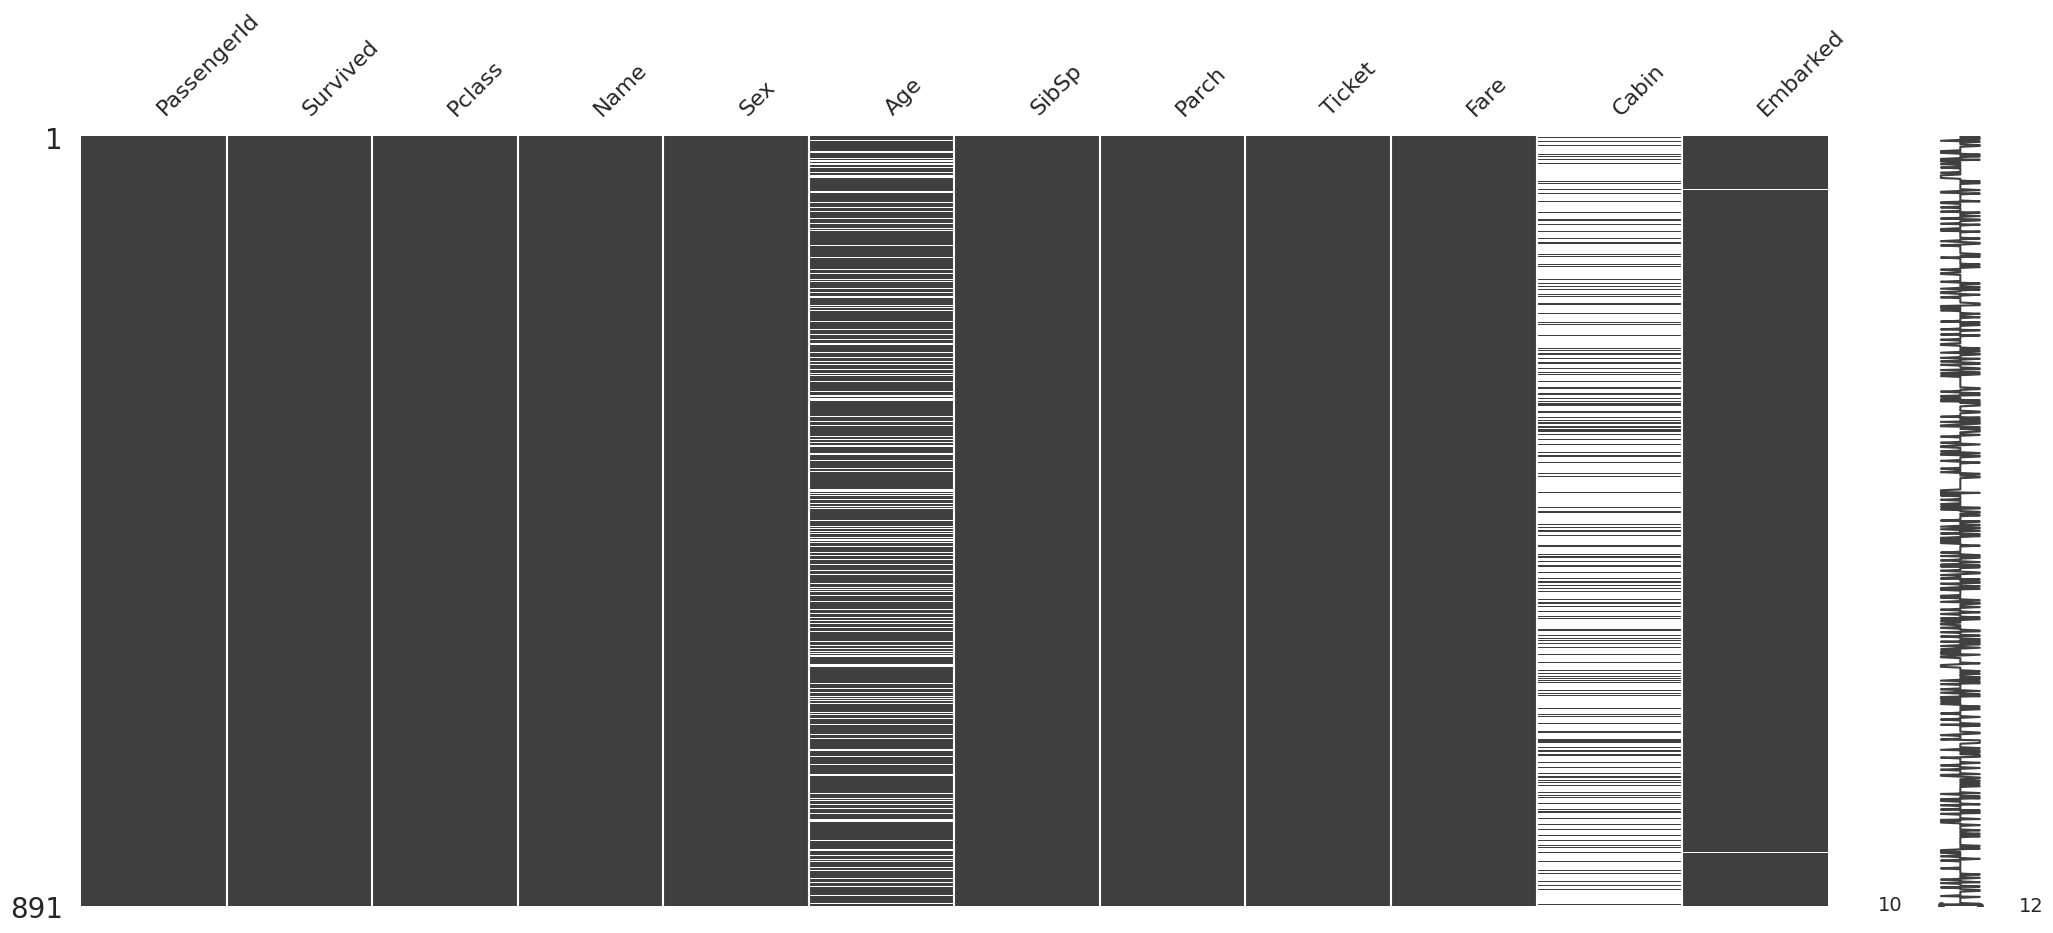

In [20]:
msno.matrix(df_train)
plt.show()

### 데이터 전처리

In [21]:
# 1. Age - 중앙값으로 채우기
df_train['Age'].fillna(df_train['Age'].median(), inplace=True)
df_test['Age'].fillna(df_test['Age'].median(), inplace=True)
# fillna - null값을 원하는 값으로 채우는 함수
# median - 중앙값 (정확히 가운데에 있는 값)
# inplace - 원본을 직접 수정할지 말지 결정하는 옵션

# 2. Cabin - null이 너무 많으니 드랍
df_train.drop('Cabin', axis=1, inplace=True)
df_test.drop('Cabin', axis=1, inplace=True)
# drop - 행이나 컬럼을 삭제하는 함수

# 3. Embarked - 최빈값(S)으로 채우기
df_train['Embarked'].fillna('S', inplace=True)
# 최빈값 - 가장 자주 나타나는(빈도수가 가장 높은) 값

# 4. 확인
print(df_train.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### EDA(탐색적 분석)

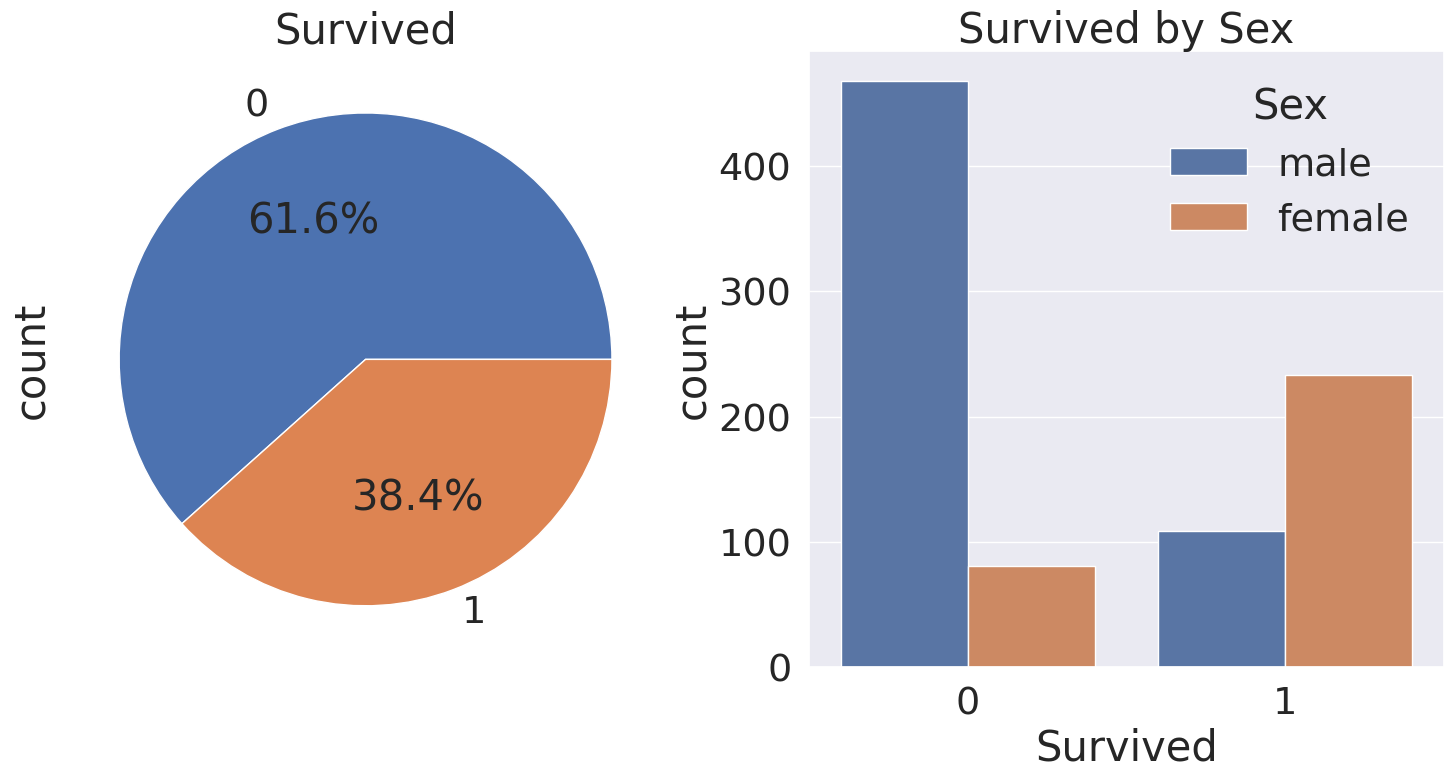

In [23]:
# 성별에 따른 생존율
f, ax = plt.subplots(1, 2, figsize=(18, 8))
# subplot - 그래프를 여러 개 나란히 그리는 함수
# figsize 전체 그래프 크기

df_train['Survived'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Survived')
# value_counts - 각 값이 몇개인지 세는 함수
# ax - 이 그래프를 어디에 그릴지 지정
# ax[0] = 왼쪽
# ax[1] = 가운데
# ax[2] = 오른쪽
# autopct - 파이차트에 퍼센트 표시
# sns.countplot 카테고리별 개수를 막대그래프로 그리는 함수

sns.countplot(x='Survived', hue='Sex', data=df_train, ax=ax[1])
ax[1].set_title('Survived by Sex')
# hue 막대를 한번 더 나눠서 색으로 구분 (hue 범주형데이터)

plt.show()

### Pclass(등급)별 생존율

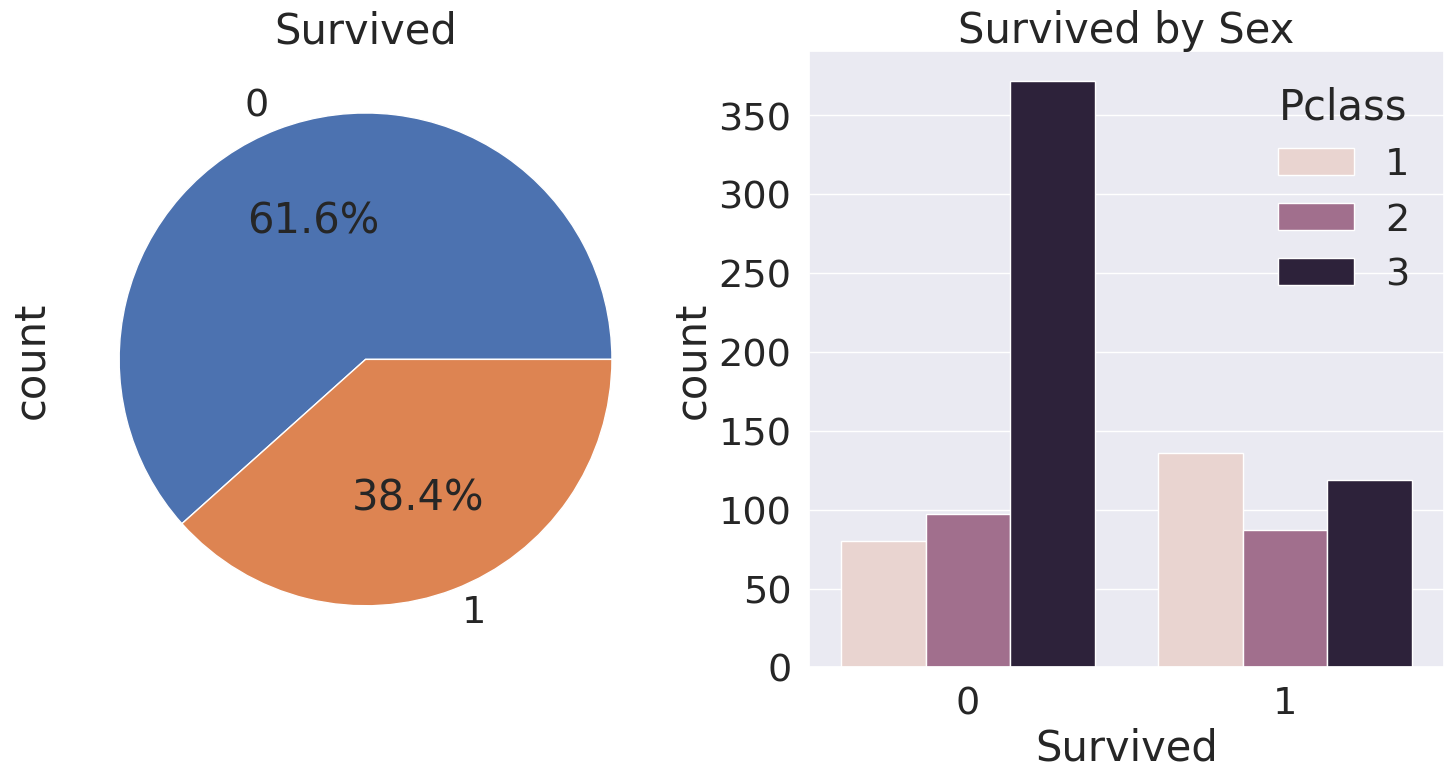

In [24]:
# 성별에 따른 생존율
f, ax = plt.subplots(1, 2, figsize=(18, 8))
# subplot - 그래프를 여러 개 나란히 그리는 함수
# figsize 전체 그래프 크기

df_train['Survived'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Survived')
# value_counts - 각 값이 몇개인지 세는 함수
# ax - 이 그래프를 어디에 그릴지 지정
# autopct - 파이차트에 퍼센트 표시
# sns.countplot 카테고리별 개수를 막대그래프로 그리는 함수

sns.countplot(x='Survived', hue='Pclass', data=df_train, ax=ax[1])
ax[1].set_title('Survived by Sex')
# hue 막대를 한번 더 나눠서 색으로 구분 (hue 범주형데이터)

plt.show()

### Age(나이)별 생존율

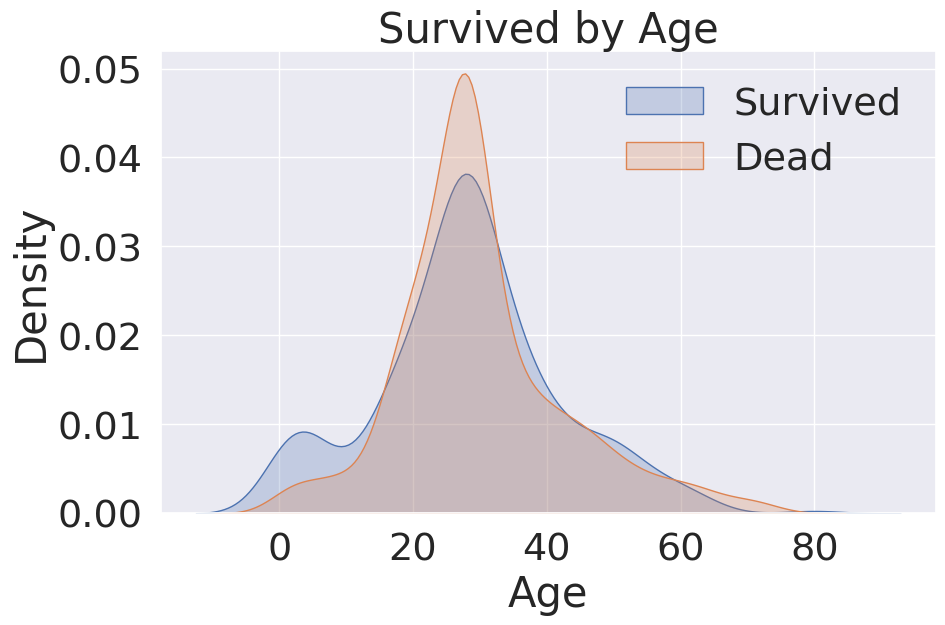

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.kdeplot(df_train[df_train['Survived'] == 1]['Age'], label='Survived', shade=True)
# kdeplot - 데이터 분포를 부드러운 곡선으로 보여주는 그래프
# 데이터 필터링 == 1 생존한 사람 == 0 사망한 사람
# shade 곡선 아래를 색으로 채워줌

sns.kdeplot(df_train[df_train['Survived'] == 0]['Age'], label='Dead', shade=True)

plt.title('Survived by Age')
plt.legend()
# legend 범례표시 어떤색인지 알려주는 것
plt.show()

### SibSp / Parch(가족 수)별 생존율

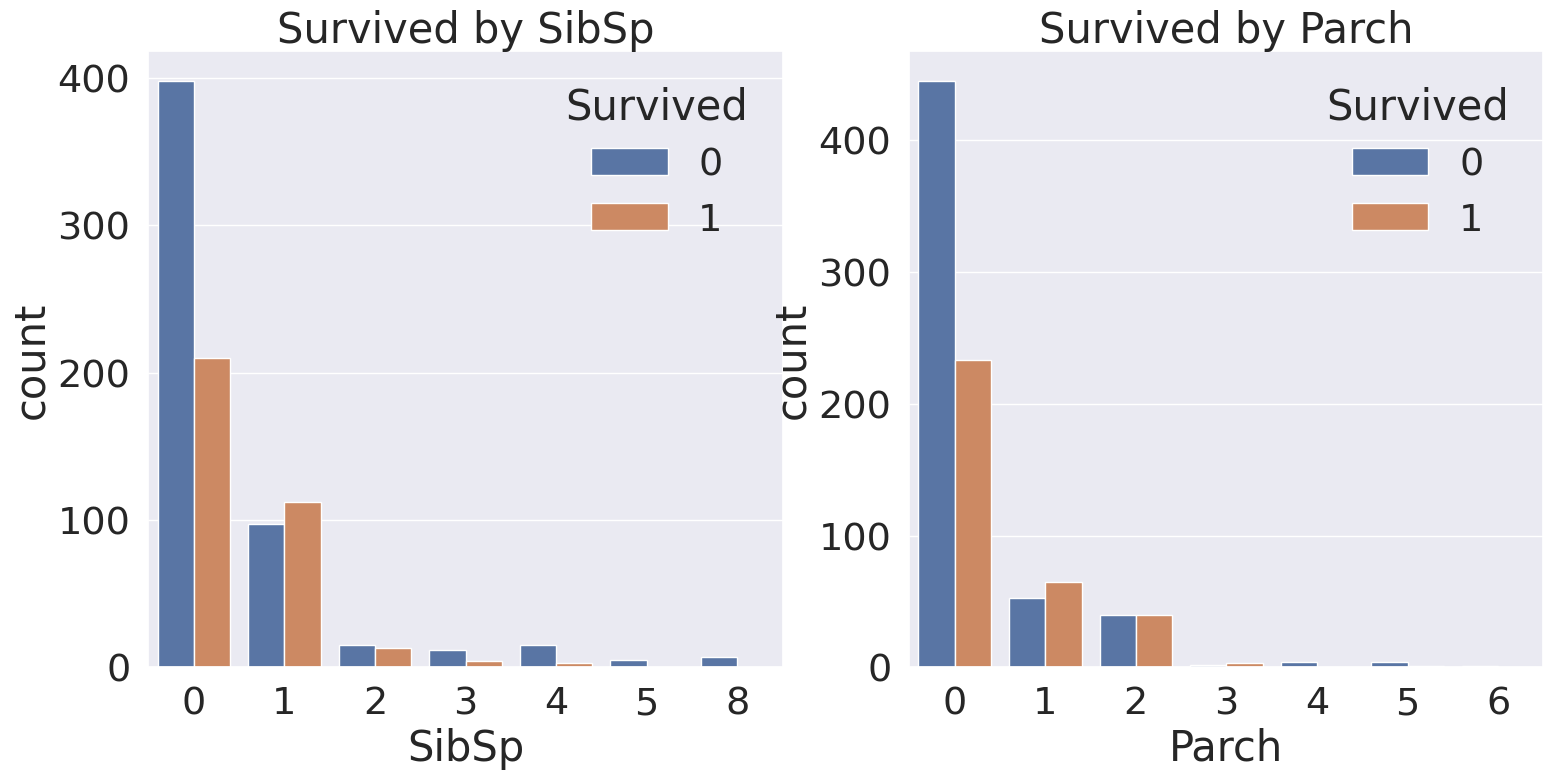

In [26]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

sns.countplot(x='SibSp', hue='Survived', data=df_train, ax=ax[0])
ax[0].set_title('Survived by SibSp')
# SibSp = Siblings + Spouse → 함께 탄 형제 + 배우자 수

sns.countplot(x='Parch', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('Survived by Parch')
# Parch = Parents + Children → 함께 탄 부모 + 자녀 수

plt.show()

### 보고싶은 관점에 따라 반대로 작성을 통해 보여질 수 있다.

x='Survived', hue='Sex' → "생존/사망 중에 남녀 비율이 어떤지?"

x='SibSp', hue='Survived' → "형제 수별로 생존/사망이 어떤지?"

### Embarked(탑승 항구)별 생존율

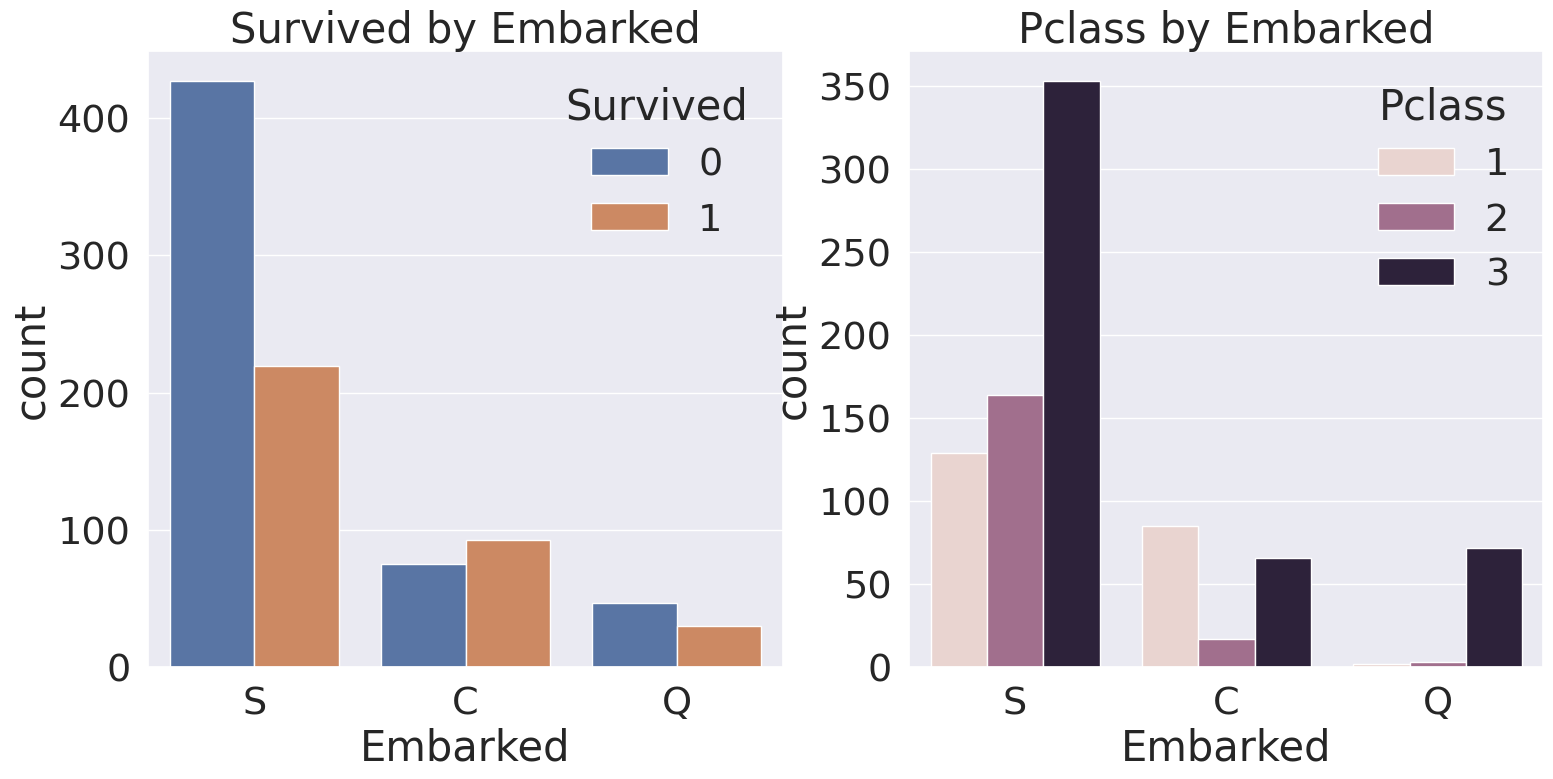

In [27]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

sns.countplot(x='Embarked', hue='Survived', data=df_train, ax=ax[0])
ax[0].set_title('Survived by Embarked')
# 항구별 생존/사망 비교

sns.countplot(x='Embarked', hue='Pclass', data=df_train, ax=ax[1])
ax[1].set_title('Pclass by Embarked')
# 항구별 어떤 등급 승객이 많았는지

plt.show()


# C에서 1등석 승객이 많이 탔기 때문

왼쪽그래프
- S — 사망 ~430, 생존 ~220 → 생존율 약 34%
- C — 사망 ~75, 생존 ~95 → 생존율 약 55%
- Q — 사망 ~50, 생존 ~30 → 생존율 약 38%

====================================

오른쪽 그래프
- C에서 1등석(연한색)이 제일 많고 1등석 = 부자 = 먼저 구조 → 그래서 C의 생존율이 높다

### 피처 엔지니어링 (문자열 → 숫자 변환 등)

In [28]:
# Sex: male → 0, female → 1
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})
# map 값을 다른 값으로 변환(매핑) 해주는 함수 (이건 이걸로 바꿔)

# Embarked: S → 0, C → 1, Q → 2
df_train['Embarked'] = df_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 학습에 필요 없는 컬럼 제거
df_train.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
df_test.drop(['Name', 'Ticket'], axis=1, inplace=True)

print(df_train.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


### 모델 학습 및 예측

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 피처(X)와 타겟(y) 분리
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# 학습용 / 검증용 데이터 나누기
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤포레스트 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 검증 데이터로 예측
pred = model.predict(X_val)

# 정확도 확인
print(f'Accuracy: {accuracy_score(y_val, pred):.4f}')

Accuracy: 0.8268


### test 데이터로 예측해서 제출 파일

In [30]:
# test 데이터에서 필요 없는 컬럼 확인
print(df_test.columns)

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


### 테스트에서 예측하고 제출 파일 만들기

In [31]:
# test에서 PassengerId 따로 빼두고 피처만 사용
X_test = df_test.drop('PassengerId', axis=1)

# Fare에 null이 있을 수 있으니 처리
X_test['Fare'].fillna(X_test['Fare'].median(), inplace=True)

# 예측
prediction = model.predict(X_test)

# 제출용 CSV 만들기
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': prediction
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
